# Run 8 - Joint Training after Making Kaggle Look Like DeepPCB (grayscale + binarized)

**Why:** Kaggle/HRIPCB images are full **color**; DeepPCB images are **binarized black-&-white**.
That appearance gap is a prime suspect for the cross-modality failures. This experiment removes the
appearance difference by applying DeepPCB's *own* documented preprocessing to the Kaggle images and
re-running the joint experiment.

**Exact transform (from the DeepPCB paper / repo README):** images are converted to grayscale and then
*"a threshold is carefully selected to employ binarization to avoid illumination disturbance."*
We replicate this literally: **grayscale -> global (Otsu) threshold -> pure binary**, written back as
3-channel JPEGs. Bounding-box labels are unchanged (only pixels are transformed).

Section 4b verifies against a real DeepPCB image (pixel histogram + foreground ratio) so the Kaggle
binarization matches DeepPCB's actual statistics, then calibrates the threshold to that foreground ratio.

Everything else (model, imgsz, seed, epochs, augmentation) is identical to Run6.
Source: DeepPCB README - https://github.com/tangsanli5201/DeepPCB

## 1. Environment

In [1]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

PyTorch : 2.5.1+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 3090


In [2]:
import subprocess, sys
try:
    import ultralytics, kagglehub, yaml, cv2
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install",
                    "ultralytics","kagglehub","pyyaml","opencv-python-headless","-q"], check=True)
    import ultralytics, kagglehub, yaml, cv2
print("ultralytics:", ultralytics.__version__)
print("opencv     :", cv2.__version__)

ultralytics: 8.4.41
opencv     : 4.10.0


## 2. Configuration

In [3]:
from pathlib import Path
import os

_cwd = Path(os.getcwd()).resolve()
ROOT_ENV = os.environ.get("PCB_PROJECT_ROOT")
if ROOT_ENV:
    PROJECT_ROOT = Path(ROOT_ENV).resolve()
elif _cwd.name == "experiments":
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "experiments").exists():
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = _cwd

SEED, IMG_SIZE, BATCH, DEVICE = 42, 640, 16, 0      # DEVICE='cpu' if no GPU
EPOCHS   = 200                                       # protocol-matched to Run1/Run2/Run6
EXP_NAME = "exp_008_yolov11n_joint_kaggle_bw"

# Unified class space == Run2 training order (DeepPCB conversions already use it)
NAMES = ['mouse_bite','spur','missing_hole','short','open_circuit','spurious_copper']

# DeepPCB raw type (1-6) -> unified index
DEEPPCB_TO_UNIFIED = {1:4, 2:3, 3:0, 4:1, 5:5, 6:2}
# 1=open->open_circuit(4) 2=short(3) 3=mousebite(0) 4=spur(1) 5=copper->spurious(5) 6=pin-hole->missing_hole(2)

DEEPPCB_DIR  = PROJECT_ROOT / "DeepPCB"            # cloned by run3 notebook
DEEPPCB_YOLO = PROJECT_ROOT / "deeppcb_yolo"        # test split already converted by run3
RESULTS_DIR  = PROJECT_ROOT / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MERGED   = PROJECT_ROOT / "joint_dataset_bw"
KAG_BW   = PROJECT_ROOT / "kaggle_bw"   # binarized copy of Kaggle
BINARIZE_METHOD = "otsu"   # automatic global threshold (DeepPCB style)
CALIBRATE_TO_DEEPPCB = True  # nudge threshold so fg ratio matches real DeepPCB

print("Project root:", PROJECT_ROOT)
print("DeepPCB repo present  :", DEEPPCB_DIR.exists())
print("DeepPCB test converted:", (DEEPPCB_YOLO/'test'/'images').exists())

Project root: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection
DeepPCB repo present  : True
DeepPCB test converted: True


## 3. Locate Kaggle dataset (color domain)

In [4]:
import yaml as _yaml
kaggle_root = kagglehub.dataset_download("norbertelter/pcb-defect-dataset")
KAG_DIR = Path(kaggle_root) / "pcb-defect-dataset"
assert (KAG_DIR/"train"/"images").exists(), f"Kaggle train images missing at {KAG_DIR}"

kag_names_raw = _yaml.safe_load((KAG_DIR/"data.yaml").read_text())["names"]
kag_names = [kag_names_raw[i] for i in range(6)] if isinstance(kag_names_raw,dict) else list(kag_names_raw)
assert kag_names == NAMES, f"Kaggle class order {kag_names} != unified {NAMES}"
print("Kaggle class order matches unified space")
for sp in ["train","valid","val","test"]:
    d = KAG_DIR/sp/"images"
    if d.exists(): print(f"  {sp:6s}: {len(list(d.glob('*')))} images")
KAG_VAL = "valid" if (KAG_DIR/"valid"/"images").exists() else "val"

  train : 8534 images
  val   : 1066 images
  test  : 1068 images


## 4. Convert DeepPCB **trainval** split to YOLO (unified space)

In [5]:
from PIL import Image
import shutil

PCBDATA = DEEPPCB_DIR / "PCBData"
assert PCBDATA.exists(), f"DeepPCB not found at {DEEPPCB_DIR} - run run3 notebook first (it clones the repo)."

tv_list = next(iter(DEEPPCB_DIR.rglob("trainval.txt")), None)
assert tv_list is not None, "trainval.txt not found in DeepPCB."
print("Using:", tv_list.relative_to(DEEPPCB_DIR))

def resolve(rel): return PCBDATA / rel

def convert_split(list_file, out_split):
    img_out = DEEPPCB_YOLO/out_split/"images"; img_out.mkdir(parents=True, exist_ok=True)
    lbl_out = DEEPPCB_YOLO/out_split/"labels"; lbl_out.mkdir(parents=True, exist_ok=True)
    n_img=n_box=skipped=0
    for line in list_file.read_text().splitlines():
        p = line.strip().split()
        if not p: continue
        img_rel = p[0]
        ann_rel = p[1] if len(p)>1 else img_rel.replace("_test.jpg",".txt")
        img_p, ann_p = resolve(img_rel), resolve(ann_rel)
        if not img_p.exists():
            stem = Path(img_rel).stem
            c = list(PCBDATA.rglob(f"{stem}_test.*")) + list(PCBDATA.rglob(f"{stem}_temp.*")) + list(PCBDATA.rglob(Path(img_rel).name))
            img_p = c[0] if c else img_p
        if not ann_p.exists():
            c=list(PCBDATA.rglob(Path(ann_rel).name)); ann_p=c[0] if c else ann_p
        if not img_p.exists() or not ann_p.exists(): skipped+=1; continue
        with Image.open(img_p) as im: W,H = im.size
        rows=[]
        for raw in ann_p.read_text().splitlines():
            v=raw.split()
            if len(v)<5: continue
            x1,y1,x2,y2,t = float(v[0]),float(v[1]),float(v[2]),float(v[3]),int(float(v[4]))
            if t not in DEEPPCB_TO_UNIFIED: continue
            cx,cy,bw,bh = (x1+x2)/2/W,(y1+y2)/2/H,(x2-x1)/W,(y2-y1)/H
            if bw<=0 or bh<=0: continue
            rows.append(f"{DEEPPCB_TO_UNIFIED[t]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"); n_box+=1
        shutil.copy2(img_p, img_out/f"{img_p.stem}.jpg")
        (lbl_out/f"{img_p.stem}.txt").write_text("\n".join(rows))
        n_img+=1
    return n_img, n_box, skipped

if (DEEPPCB_YOLO/"trainval"/"images").exists() and len(list((DEEPPCB_YOLO/"trainval"/"images").glob("*.jpg")))>0:
    print("DeepPCB trainval already converted")
else:
    ni,nb,sk = convert_split(tv_list, "trainval")
    print(f"Converted trainval: {ni} images, {nb} boxes (skipped {sk})")
    assert ni>0 and nb>0

assert (DEEPPCB_YOLO/"test"/"images").exists(), "DeepPCB test split missing - run run3 notebook first."
print("DeepPCB test images:", len(list((DEEPPCB_YOLO/'test'/'images').glob('*.jpg'))))

Using: PCBData/trainval.txt
DeepPCB trainval already converted
DeepPCB test images: 500


## 4b. Inspect a real DeepPCB image - confirm it is binary and measure its statistics

We read actual DeepPCB test images to confirm the README's claim (pure black & white) and to capture the
**foreground (white) pixel ratio**, used to calibrate the Kaggle binarization threshold.

DeepPCB sampled 30 test images
  mean #unique gray levels : 78.0  (==2 would be perfectly binary)
  mean foreground ratio    : 0.7229  (fraction of white pixels)


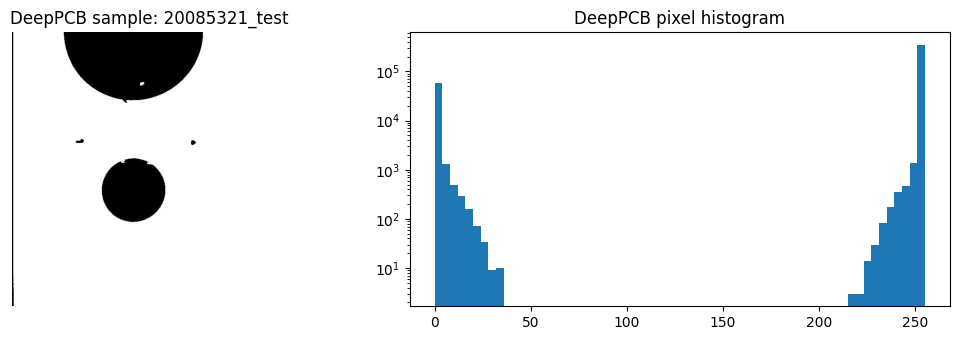

In [6]:
import random as _random, os, shutil

def link_one(ip, lbl_src, img_dst, lbl_dst, suffix=""):
    lp = lbl_src/(ip.stem+".txt")
    if not lp.exists(): return 0
    img_dst.mkdir(parents=True, exist_ok=True); lbl_dst.mkdir(parents=True, exist_ok=True)
    di = img_dst/f"{ip.stem}{suffix}{ip.suffix}"
    dl = lbl_dst/f"{ip.stem}{suffix}.txt"
    if not di.exists():
        try: os.link(ip, di)
        except OSError: shutil.copy2(ip, di)
    if not dl.exists():
        try: os.link(lp, dl)
        except OSError: shutil.copy2(lp, dl)
    return 1

def link_list(img_list, lbl_src, img_dst, lbl_dst, suffix=""):
    n=0
    for ip in img_list: n += link_one(ip, lbl_src, img_dst, lbl_dst, suffix)
    return n

def imgs_in(d):
    return sorted(Path(d).glob("*.[jJpP][pPnN][gG]*"))

import cv2, numpy as np
import matplotlib.pyplot as plt
import random as _r; _r.seed(SEED)

_dp_pool = sorted((DEEPPCB_YOLO/'test'/'images').glob('*.jpg'))
dp_samples = _r.sample(_dp_pool, min(30, len(_dp_pool)))

fg_ratios, uniq_counts = [], []
for p in dp_samples:
    g = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    uniq_counts.append(len(np.unique(g)))
    fg_ratios.append(float((g > 127).mean()))   # fraction of bright pixels
DEEPPCB_FG_RATIO = float(np.mean(fg_ratios))
print(f"DeepPCB sampled {len(dp_samples)} test images")
print(f"  mean #unique gray levels : {np.mean(uniq_counts):.1f}  (==2 would be perfectly binary)")
print(f"  mean foreground ratio    : {DEEPPCB_FG_RATIO:.4f}  (fraction of white pixels)")

g0 = cv2.imread(str(dp_samples[0]), cv2.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1,2, figsize=(11,3.5))
ax[0].imshow(g0, cmap="gray"); ax[0].set_title(f"DeepPCB sample: {dp_samples[0].stem}"); ax[0].axis("off")
ax[1].hist(g0.ravel(), bins=64); ax[1].set_title("DeepPCB pixel histogram"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()

## 5. Binarize Kaggle to DeepPCB style (grayscale -> global threshold -> binary)

Mirrors the Kaggle directory tree into `kaggle_bw/` for **train / val / test**. Pixels are transformed;
label `.txt` files are copied unchanged. With `CALIBRATE_TO_DEEPPCB`, the per-image threshold is shifted
so the white-pixel ratio matches the real DeepPCB foreground ratio from 4b.

In [7]:
def binarize_to_deeppcb(gray):
    """grayscale uint8 -> binary uint8 (0/255), DeepPCB-style global thresholding."""
    t, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Otsu global threshold
    if CALIBRATE_TO_DEEPPCB:
        target = DEEPPCB_FG_RATIO
        lo, hi = 0.0, 255.0
        for _ in range(12):                       # binary search on threshold -> match fg ratio
            mid = (lo + hi) / 2
            if float((gray > mid).mean()) > target: lo = mid
            else: hi = mid
        t = (lo + hi) / 2
    return np.where(gray > t, 255, 0).astype(np.uint8)

def convert_kaggle_split(split):
    src_i = KAG_DIR/split/"images"; src_l = KAG_DIR/split/"labels"
    if not src_i.exists(): return 0
    dst_i = KAG_BW/split/"images"; dst_l = KAG_BW/split/"labels"
    dst_i.mkdir(parents=True, exist_ok=True); dst_l.mkdir(parents=True, exist_ok=True)
    n=0
    for ip in imgs_in(src_i):
        g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
        if g is None: continue
        b = binarize_to_deeppcb(g)
        bgr = cv2.cvtColor(b, cv2.COLOR_GRAY2BGR)   # 3-channel so YOLO input matches
        cv2.imwrite(str(dst_i/f"{ip.stem}.jpg"), bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        lp = src_l/(ip.stem+".txt")
        if lp.exists(): shutil.copy2(lp, dst_l/f"{ip.stem}.txt")
        else: (dst_l/f"{ip.stem}.txt").write_text("")
        n+=1
    return n

already = (KAG_BW/'train'/'images').exists() and len(list((KAG_BW/'train'/'images').glob('*.jpg')))>0
if already:
    print("kaggle_bw already built - delete the folder to rebuild.")
else:
    if KAG_BW.exists(): shutil.rmtree(KAG_BW)
    for sp in ["train", KAG_VAL, "test"]:
        print(f"  binarized {sp:6s}: {convert_kaggle_split(sp)} images")

chk = imgs_in(KAG_BW/'train'/'images')[0]
cg = cv2.imread(str(chk), cv2.IMREAD_GRAYSCALE)
print(f"\nKaggle_bw check {chk.stem}: unique levels={len(np.unique(cg))}, fg ratio={float((cg>127).mean()):.4f}")
print(f"DeepPCB target fg ratio                 : {DEEPPCB_FG_RATIO:.4f}")

kaggle_bw already built - delete the folder to rebuild.

Kaggle_bw check l_light_01_missing_hole_01_1_600: unique levels=20, fg ratio=0.7152
DeepPCB target fg ratio                 : 0.7229


### 5b. Visual check - original color vs DeepPCB-style binarized

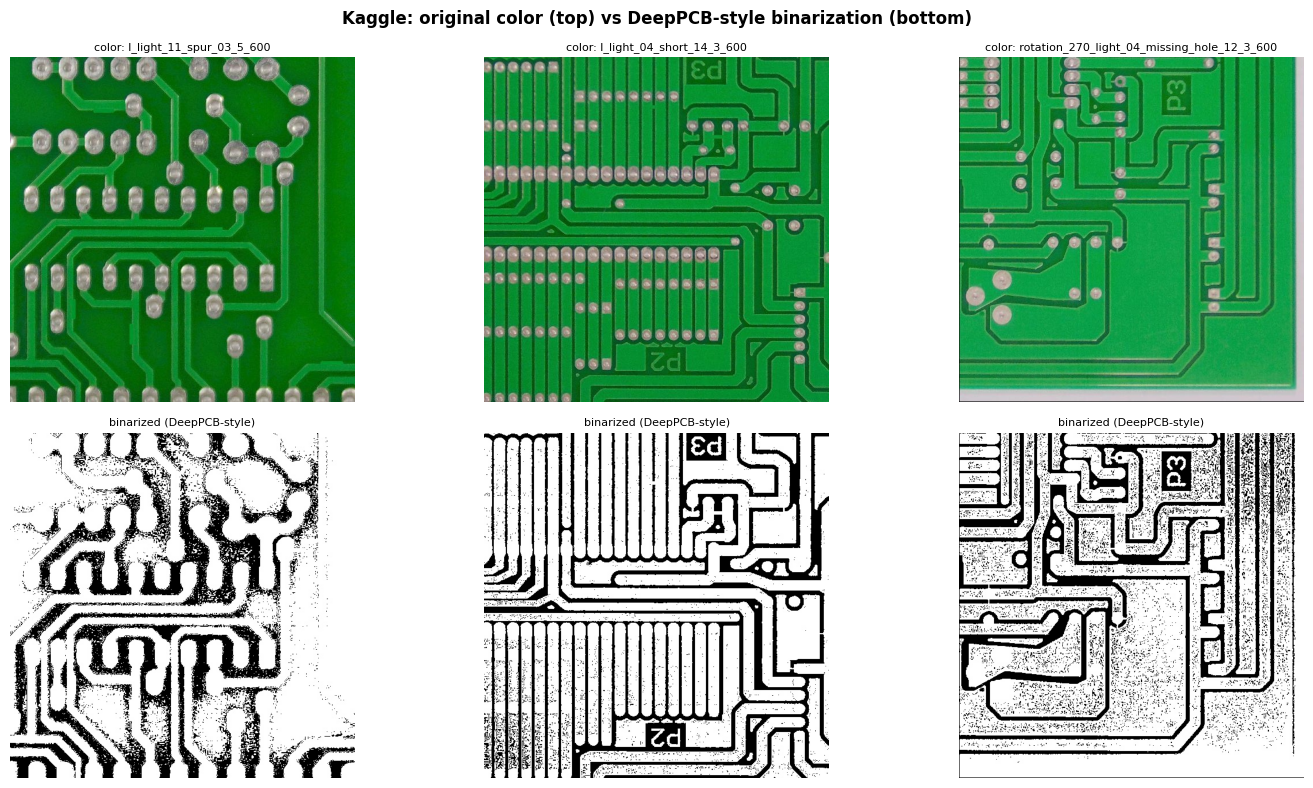

In [8]:
import matplotlib.image as mpimg
import random as _r2; _r2.seed(SEED)
samp = _r2.sample(imgs_in(KAG_DIR/'train'/'images'), 3)
fig, axes = plt.subplots(2,3, figsize=(15,8))
for j,ip in enumerate(samp):
    axes[0,j].imshow(mpimg.imread(str(ip))); axes[0,j].set_title(f"color: {ip.stem}", fontsize=8); axes[0,j].axis("off")
    bp = KAG_BW/'train'/'images'/f"{ip.stem}.jpg"
    axes[1,j].imshow(mpimg.imread(str(bp)), cmap="gray"); axes[1,j].set_title("binarized (DeepPCB-style)", fontsize=8); axes[1,j].axis("off")
plt.suptitle("Kaggle: original color (top) vs DeepPCB-style binarization (bottom)", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Build merged training set (binarized Kaggle + DeepPCB)

Same domain-balancing recipe as Run6 (DeepPCB oversampled x`DOMAIN_BALANCE`) so the **only** changed
variable vs Run6 is that Kaggle is now binarized.

In [9]:
import random as _random, os, shutil

def link_one(ip, lbl_src, img_dst, lbl_dst, suffix=""):
    lp = lbl_src/(ip.stem+".txt")
    if not lp.exists(): return 0
    img_dst.mkdir(parents=True, exist_ok=True); lbl_dst.mkdir(parents=True, exist_ok=True)
    di = img_dst/f"{ip.stem}{suffix}{ip.suffix}"
    dl = lbl_dst/f"{ip.stem}{suffix}.txt"
    if not di.exists():
        try: os.link(ip, di)
        except OSError: shutil.copy2(ip, di)
    if not dl.exists():
        try: os.link(lp, dl)
        except OSError: shutil.copy2(lp, dl)
    return 1

def link_list(img_list, lbl_src, img_dst, lbl_dst, suffix=""):
    n=0
    for ip in img_list: n += link_one(ip, lbl_src, img_dst, lbl_dst, suffix)
    return n

def imgs_in(d):
    return sorted(Path(d).glob("*.[jJpP][pPnN][gG]*"))

DOMAIN_BALANCE = 4   # same as Run6

all_dp = imgs_in(DEEPPCB_YOLO/"trainval"/"images")
_random.seed(SEED); _random.shuffle(all_dp)
cut = max(1, int(len(all_dp) * 0.10))
dp_val_imgs, dp_tr_imgs = all_dp[:cut], all_dp[cut:]
print(f"DeepPCB trainval split: {len(dp_tr_imgs)} train / {len(dp_val_imgs)} val")

TR_I, TR_L = MERGED/"train"/"images", MERGED/"train"/"labels"
VA_I, VA_L = MERGED/"val"/"images",   MERGED/"val"/"labels"
if MERGED.exists(): shutil.rmtree(MERGED)

n_kag_tr = link_list(imgs_in(KAG_BW/"train"/"images"), KAG_BW/"train"/"labels", TR_I, TR_L)
n_dp_tr = 0
for k in range(DOMAIN_BALANCE):
    n_dp_tr += link_list(dp_tr_imgs, DEEPPCB_YOLO/"trainval"/"labels", TR_I, TR_L, suffix=f"_d{k}")
n_kag_va = link_list(imgs_in(KAG_BW/KAG_VAL/"images"), KAG_BW/KAG_VAL/"labels", VA_I, VA_L)
n_dp_va  = link_list(dp_val_imgs, DEEPPCB_YOLO/"trainval"/"labels", VA_I, VA_L, suffix="_dp")

print(f"train: {n_kag_tr} Kaggle_bw + {n_dp_tr} DeepPCB (x{DOMAIN_BALANCE}) = {n_kag_tr+n_dp_tr}")
print(f"val  : {n_kag_va} Kaggle_bw + {n_dp_va} DeepPCB = {n_kag_va+n_dp_va}")

joint_yaml = MERGED/"joint.yaml"
joint_yaml.write_text(_yaml.dump({
    "path": str(MERGED), "train": "train/images", "val": "val/images",
    "names": {i:n for i,n in enumerate(NAMES)},
}, sort_keys=False))
print("\n", joint_yaml.read_text())

DeepPCB trainval split: 900 train / 100 val
train: 8534 Kaggle_bw + 3600 DeepPCB (x4) = 12134
val  : 1066 Kaggle_bw + 100 DeepPCB = 1166

 path: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/joint_dataset_bw
train: train/images
val: val/images
names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



## 7. Train (YOLOv11n, 200 ep, imgsz 640, seed 42 - protocol identical to Run6)

In [10]:
from ultralytics import YOLO

AUG = dict(   # identical to Run6 so the only changed variable is the dataset composition
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.5,
    degrees=10.0, translate=0.10, scale=0.5, shear=2.0,
    flipud=0.5, fliplr=0.5,
    mosaic=1.0, mixup=0.10, copy_paste=0.0,
)

model = YOLO("yolo11n.pt")
results = model.train(
    data=str(joint_yaml), epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH, device=DEVICE,
    seed=SEED, deterministic=True,
    project=str(RESULTS_DIR), name=EXP_NAME, exist_ok=True,
    patience=50, **AUG,
)
BEST = RESULTS_DIR/EXP_NAME/"weights"/"best.pt"
print("\nbest.pt:", BEST, BEST.exists())

New https://pypi.org/project/ultralytics/8.4.80 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24124MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/joint_dataset_bw/joint.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=tra

## Per-domain test yamls

In [11]:
EVAL_DIR = MERGED/"eval"; EVAL_DIR.mkdir(parents=True, exist_ok=True)
BEST = RESULTS_DIR/EXP_NAME/"weights"/"best.pt"

KAG_TEST_ROOT = KAG_BW
kag_test_yaml = EVAL_DIR/"kaggle_test.yaml"
kag_test_yaml.write_text(_yaml.dump({
    "path": str(KAG_TEST_ROOT), "train":"test/images","val":"test/images","test":"test/images",
    "names": {i:n for i,n in enumerate(NAMES)}}, sort_keys=False))

dp_test_yaml = EVAL_DIR/"deeppcb_test.yaml"
dp_test_yaml.write_text(_yaml.dump({
    "path": str(DEEPPCB_YOLO), "train":"test/images","val":"test/images","test":"test/images",
    "names": {i:n for i,n in enumerate(NAMES)}}, sort_keys=False))
print("eval yamls ready")

eval yamls ready


## Evaluate the joint model on every test domain

In [12]:
import pandas as pd
from ultralytics import YOLO

joint = YOLO(str(BEST))

def ev(yaml_path, tag):
    r = joint.val(data=str(yaml_path), split="test", imgsz=IMG_SIZE, batch=BATCH, device=DEVICE,
                  project=str(RESULTS_DIR), name=f"{EXP_NAME}_on_{tag}", exist_ok=True,
                  plots=False, verbose=False)
    m50, m = float(r.box.map50), float(r.box.map)
    idx  = list(r.box.ap_class_index)
    ap50 = {int(c):float(a) for c,a in zip(idx, r.box.ap50)}
    pc = pd.DataFrame({"Class":NAMES, "AP@50":[round(ap50.get(i,float('nan')),4) for i in range(6)]})
    print(f"\nJoint -> {tag}:  mAP50={m50:.4f}  mAP50-95={m:.4f}")
    print(pc.to_string(index=False))
    pc.to_csv(RESULTS_DIR/f"{EXP_NAME}_on_{tag}_perclass.csv", index=False)
    return m50, m

j_kag50, j_kag = ev(kag_test_yaml, "kaggle")
j_dp50,  j_dp  = ev(dp_test_yaml,  "deeppcb")

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24124MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 540.4±113.8 MB/s, size: 247.3 KB)
val: Scanning /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/kaggle_bw/test/labels... 1068 images, 239 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 1.3Kit/s 0.8s0.0s
val: New cache created: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/kaggle_bw/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 30.4it/s 2.2s0.1s
                   all       1068       1662      0.909        0.9      0.954      0.539
Speed: 0.3ms preprocess, 1.1ms inference, 0.0ms loss, 0.2ms postprocess per image

Joint -> kaggle:  mAP50=0.9545  mAP50-95=0.5394
          Class  AP@50
     mouse_bite 0.9714
           spur 0.9526
   missing

## Compare against Run6 (the unmodified joint baseline)

In [13]:
import pandas as pd
LABEL = "Run8 Kaggle-binarized"

# Pull Run6's joint numbers from its saved per-class CSVs (macro-avg AP@50 ~= mAP50)
def run6_map(tag):
    f = RESULTS_DIR/f"exp_006_yolov11n_joint_kaggle_deeppcb_cleanval_on_{tag}_perclass.csv"
    if not f.exists(): return None
    return round(float(pd.read_csv(f)["AP@50"].mean()), 4)

rows = [
    {"Experiment":"Run6 joint (baseline)", "Kaggle test":run6_map("kaggle"), "DeepPCB test":run6_map("deeppcb")},
    {"Experiment":LABEL,                    "Kaggle test":round(j_kag50,4),     "DeepPCB test":round(j_dp50,4)},
]
cmp = pd.DataFrame(rows)
cmp.to_csv(RESULTS_DIR/f"{EXP_NAME}_vs_run6.csv", index=False)
print("====  " + LABEL + " vs Run6  (mAP@50)  ====")
print(cmp.to_string(index=False))
print("\nNote: Run6 per-class CSV means approximate its mAP@50 (macro-avg of the 6 classes).")

====  Run8 Kaggle-binarized vs Run6  (mAP@50)  ====
           Experiment  Kaggle test  DeepPCB test
Run6 joint (baseline)       0.8045        0.9788
Run8 Kaggle-binarized       0.9545        0.9798

Note: Run6 per-class CSV means approximate its mAP@50 (macro-avg of the 6 classes).


## Comparison heatmap

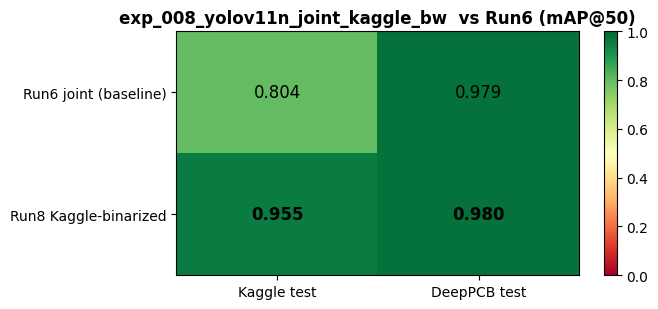

Saved: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_008_yolov11n_joint_kaggle_bw_vs_run6_heatmap.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

cols = ["Kaggle test","DeepPCB test"]
arr = np.array([[r[c] if r[c] is not None else np.nan for c in cols] for _,r in cmp.iterrows()], dtype=float)
fig, ax = plt.subplots(figsize=(7,3.2))
im = ax.imshow(arr, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_yticks(range(len(cmp))); ax.set_yticklabels(cmp["Experiment"])
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        v = arr[i,j]
        ax.text(j,i, f"{v:.3f}" if not np.isnan(v) else "N/A", ha="center", va="center",
                fontsize=12, fontweight="bold" if i==1 else "normal",
                color="white" if (not np.isnan(v) and v<0.35) else "black")
plt.colorbar(im, ax=ax)
ax.set_title(f"{EXP_NAME}  vs Run6 (mAP@50)", fontweight="bold")
plt.tight_layout()
hp = RESULTS_DIR/f"{EXP_NAME}_vs_run6_heatmap.png"
plt.savefig(hp, dpi=150, bbox_inches="tight"); plt.show()
print("Saved:", hp)

## Qualitative: joint model on both modalities

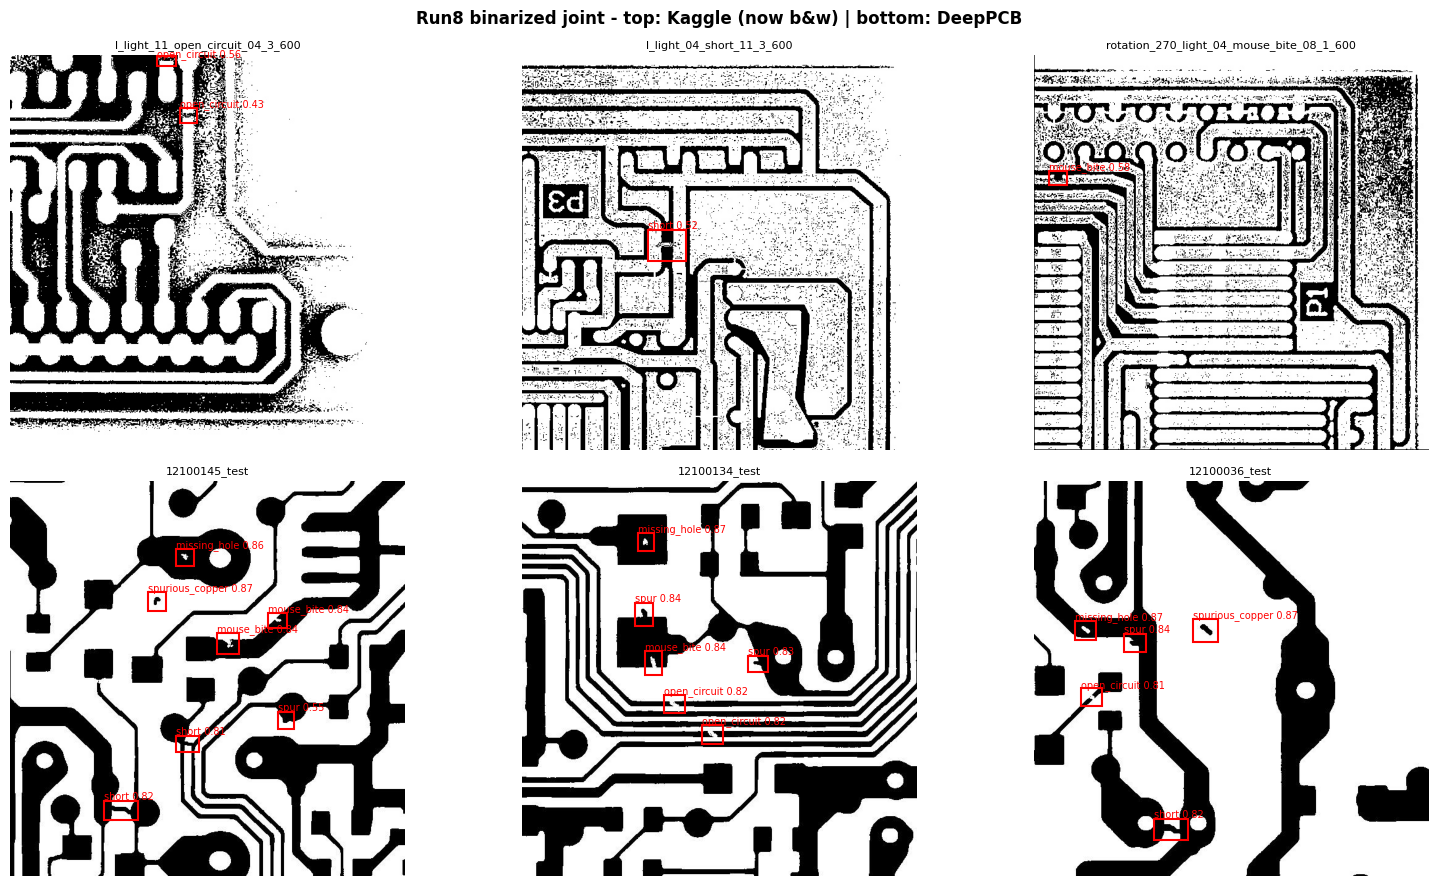

Saved: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_008_yolov11n_joint_kaggle_bw_qual_both_domains.png


In [15]:
import matplotlib.image as mpimg, random
random.seed(SEED)
kag_imgs = random.sample(imgs_in(KAG_TEST_ROOT/"test"/"images"), 3)
dp_imgs  = random.sample(imgs_in(DEEPPCB_YOLO/"test"/"images"), 3)

fig, axes = plt.subplots(2,3, figsize=(16,9))
for ax, ip in zip(axes.flat, kag_imgs+dp_imgs):
    res = joint.predict(str(ip), imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    im = mpimg.imread(str(ip)); ax.imshow(im, cmap="gray")
    for b in res.boxes:
        x1,y1,x2,y2 = b.xyxy[0].tolist()
        ax.add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1, lw=1.5, edgecolor="red", facecolor="none"))
        ax.text(x1,max(y1-3,0), f"{NAMES[int(b.cls)]} {float(b.conf):.2f}", color="red", fontsize=7)
    ax.set_title(ip.stem, fontsize=8); ax.axis("off")
plt.suptitle("Run8 binarized joint - top: Kaggle (now b&w) | bottom: DeepPCB", fontweight="bold")
plt.tight_layout()
qp = RESULTS_DIR/f"{EXP_NAME}_qual_both_domains.png"
plt.savefig(qp, dpi=120); plt.show()
print("Saved:", qp)

## What this isolates

Run6 vs Run8 differ in **one** thing: Run8's Kaggle images are binarized to DeepPCB's exact appearance
(grayscale + global threshold). The Kaggle test set here is **also** binarized, so the Kaggle column is
evaluated in the same b&w domain the model trained on.

- If the binarized-Kaggle score **stays high** -> color was not carrying the signal; the detector copes
  with the b&w appearance and the modality gap is about appearance, not lost color information.
- If it **drops** -> color/contrast cues the network relied on are destroyed by binarization, i.e. the
  HRIPCB defects are partly defined by color the DeepPCB style throws away.
- Comparing the DeepPCB column across Run6/Run8 shows whether unifying the *appearance* of the two
  domains reduces the cross-modality interference seen in the original joint model.